# All-dielectric metasurface absorber: periodic cell and finite array

A Beamz recreation of the official [Tidy3D dielectric metasurface absorber example](https://www.flexcompute.com/tidy3d/examples/notebooks/DielectricMetasurfaceAbsorber/). The geometry follows Fan et al., *All-dielectric metasurface absorbers for uncooled terahertz imaging*, Optica 4, 601–604 (2017), [DOI: 10.1364/OPTICA.4.000601](https://doi.org/10.1364/OPTICA.4.000601).

Follow the original sequence: materials and geometry → source spectrum → mesh/layout → unit-cell simulation → R/T/A spectra → resonant field intensity → 15 × 15 finite array under a Gaussian beam → spectra and field maps.

The unit cell retains the published 40-cell-per-wavelength target. The finite array retains all 225 resonators and the original beam waist, but defaults to a **coarse 8-cell-per-wavelength mesh** so it can run on a 24 GB GPU. Set `finite_steps_per_wavelength = 30` to request the source’s finite-array target on a larger machine. A matching coarse periodic run separates mesh changes from finite-array effects. The notebooks do not use Tidy3D symmetry reductions; all plotted curves and fields are computed by Beamz.

## Imports and setup

From the repository: `uv sync --extra dev`, then use that Python kernel. A compatible JAX CUDA installation is recommended for the finite-array section. CPU JAX is supported but considerably slower. Leave the adjacent `_metasurface_utils.py` beside the notebooks.

The notebook executes both unit-cell and finite-array sections. The latter can take several minutes and uses substantially more memory. Results remain in the saved notebook, so rerunning is not required to inspect the plots.

In [1]:
from pathlib import Path
import sys
import platform
import time

import jax
import matplotlib.pyplot as plt
import numpy as np
import beamz as bz
from beamz.design.raster import Scene, Object, Cylinder, Box

# Works when launched from either the repository or examples/notebooks.
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "examples/notebooks/_metasurface_utils.py").exists())
sys.path.insert(0, str(REPO / "examples/notebooks"))
from _metasurface_utils import (layered_axis, run_case, plane_amplitude,
                               release_device_memory, plot_setup, field_intensity)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.grid": True, "grid.alpha": .22,
                     "lines.linewidth": 1.8})
print(f"Python {platform.python_version()}; JAX {jax.__version__}; {jax.devices()}")

Python 3.11.15; JAX 0.10.2; [CudaDevice(id=0)]


## Simulation setup: frequencies and materials

Match the original 0.4–0.8 THz band with 100 frequency samples and a 0.6 THz carrier. The silicon has Drude ε∞ = 11.7, plasma frequency 0.69 THz, and damping 0.83 THz in Tidy3D’s cyclic-frequency convention. Beamz’s Drude constructor takes angular frequencies, so both values are multiplied by **2π**.

PDMS has relative permittivity 1.72 and loss tangent 0.15 at 0.6 THz. As in Tidy3D’s `Medium.from_nk`, represent this with constant permittivity and conductivity: σ = ε₀ω₀ε′tanδ. Its loss tangent varies as 1/f outside the center frequency; it is not a broadband constant-loss-tangent model.

In [2]:
THz, um = 1e12, 1e-6
freqs = np.linspace(.4 * THz, .8 * THz, 100)
freq0, frequency_width = .6 * THz, .4 * THz
lambda0 = bz.LIGHT_SPEED / freq0
pulse = bz.GaussianPulse(freq0=freq0, fwidth=.5 * frequency_width)
si = bz.PoleResidue.drude(
    epsilon_inf=11.7, plasma_frequency=2*np.pi*.69*THz,
    damping=2*np.pi*.83*THz, frequency_range=(.4*THz, .8*THz))
pdms_epsilon, pdms_loss_tangent = 1.72, .15
pdms_sigma = bz.EPS_0 * 2*np.pi*freq0 * pdms_epsilon * pdms_loss_tangent
pdms = bz.Material(permittivity=pdms_epsilon, conductivity=pdms_sigma)
air = bz.Material(permittivity=1)

# Independent material-response check catches Hz/rad/s conversion mistakes.
expected_si = 11.7 - (.69*THz)**2 / (freqs**2 + 1j*freqs*.83*THz)
np.testing.assert_allclose(si.eps_model(freqs), expected_si, rtol=1e-12)
pdms_response = pdms_epsilon + 1j*pdms_sigma / (bz.EPS_0 * 2*np.pi*freqs)
np.testing.assert_allclose(pdms_response[np.argmin(abs(freqs-freq0))].real, 1.72)
print(f"PDMS conductivity: {pdms_sigma:.5f} S/m")

PDMS conductivity: 8.61191 S/m


## Geometry, domain, and grid

Use period 330 µm, cylinder radius 106 µm, cylinder height 85 µm, and an 8 µm PDMS sheet. The unit-cell z extent is two center wavelengths. The explicit graded grid resolves the silicon at the requested wavelength target, snaps the sheet/disk interfaces, and expands into the air buffers. This follows the source’s resolution policy with a different grid-generation algorithm.

The exact same rectilinear grid is reused for the vacuum reference and resonator run. The finite-array section uses a cubic uniform mesh, required by the current Gaussian beam source, while the main periodic cell uses the graded grid. Native raster cylinders avoid approximating the disks with polygons.

In [3]:
p, radius, h, sheet_thickness = 330*um, 106*um, 85*um, 8*um
Lz = 2 * lambda0
run_time = 3e-10
unit_steps_per_wavelength = 40
finite_steps_per_wavelength = 8  # Source notebook: 30; needs a larger machine.
finite_count = 15                # Same 15 × 15 array as the source notebook.
beam_waist = 3 * lambda0
pml_thickness = .2 * lambda0
source_z, transmission_z, reflection_z = .3*lambda0, -.4*Lz, .4*Lz


def absorber_grid(width, steps_per_wavelength, *, periodic, uniform=False):
    silicon_spacing = lambda0 / (np.sqrt(si.epsilon_inf) * steps_per_wavelength)
    if uniform:
        # GaussianBeamSource currently needs a cubic uniform Yee grid.
        # Use an integer number of cells per lattice period for both comparison runs.
        dl = p / int(np.ceil(p / silicon_spacing))
        nx = int(np.ceil(width / dl))
        nz = int(np.ceil(Lz / dl))
        return bz.RectilinearGrid.from_spacing(
            (nx, nx, nz), dl, origin=(-nx*dl/2, -nx*dl/2, -nz*dl/2))
    count = int(np.ceil(width / silicon_spacing))
    lateral = np.linspace(-width/2, width/2, count + 1)
    z = layered_axis(-Lz/2, Lz/2, [-sheet_thickness, 0, h],
                     silicon_spacing, lambda0 / steps_per_wavelength)
    return bz.RectilinearGrid(lateral, lateral, z)


def absorber_scene(width, *, count=1, device=True):
    # Unused dispersive media would allocate unnecessary ADE state.
    if not device:
        return Scene(materials=(air,))
    objects = []
    if device:
        objects.append(Object(Box((-width/2, -width/2, -sheet_thickness),
                                  (width/2, width/2, 0)), 1))
        coordinates = p * (np.arange(count) - (count - 1)/2)
        objects.extend(Object(Cylinder((x, y), radius, 0, h), 2, priority=1)
                       for x in coordinates for y in coordinates)
    return Scene(materials=(air, pdms, si), objects=tuple(objects))


def absorber_simulation(*, steps=unit_steps_per_wavelength, finite=False, device=True, uniform=False):
    width = finite_count*p + lambda0 if finite else p
    grid = absorber_grid(width, steps, periodic=not finite, uniform=finite or uniform)
    width = np.ptp(grid.x_edges)
    # Sources and power monitors stay outside transverse PML in the finite case.
    aperture_width = width - 2*pml_thickness if finite else width
    aperture = (aperture_width, aperture_width, 0)
    source_type = bz.GaussianBeamSource if finite else bz.PlaneWaveSource
    beam_kwargs = {"waist_radius": beam_waist} if finite else {}
    source = source_type(center=(0, 0, source_z), size=aperture,
                         source_time=pulse, direction="-z", pol_angle=0, **beam_kwargs)
    monitors = [bz.FluxMonitor(center=(0, 0, position), size=aperture,
                               freqs=freqs, interval=8, name=name)
                for name, position in [("T", transmission_z), ("R", reflection_z)]]
    if device:
        monitors.append(bz.FieldMonitor(
            center=(0, 0, 0), size=(width, 0, lambda0), freqs=[freq0],
            fields=("Ex", "Ey", "Ez"), interval=8, name="resonance_xz"))
        if finite:
            monitors.append(bz.FieldMonitor(
                center=(0, 0, 0), size=(aperture_width, aperture_width, 0),
                freqs=[freq0], fields=("Ex", "Ey", "Ez"), interval=8, name="array_xy"))
    boundaries = ([bz.PML(thickness=pml_thickness, formulation="cpml")] if finite else
                  [bz.Periodic(axes=("x", "y")),
                   bz.PML(edges=("front", "back"), thickness=pml_thickness,
                          formulation="cpml")])
    return bz.Simulation(
        scene=absorber_scene(width, count=finite_count if finite else 1, device=device),
        raster_grid=grid, run_time=run_time, sources=[source], monitors=monitors,
        boundaries=boundaries)

## Source spectrum and geometry checks

Show the source band before execution, then cross sections and realized mesh. The pulse width and spectrum cover the entire requested THz interval.

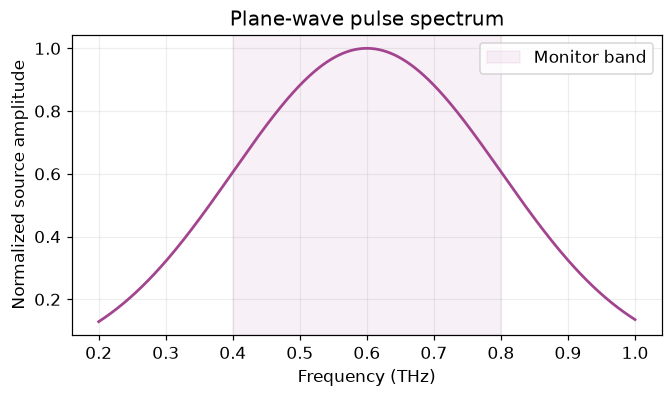

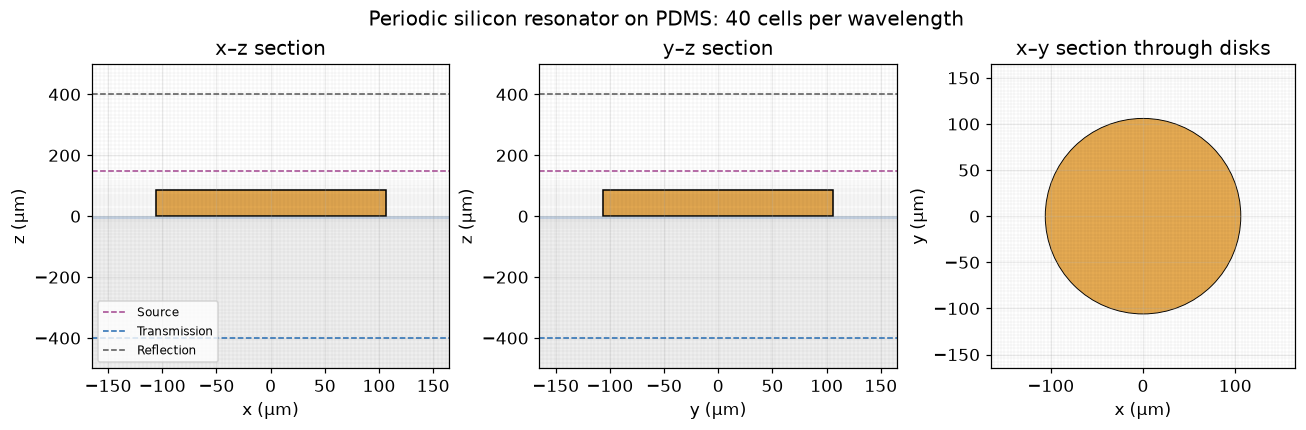

Unit-cell mesh: (91, 91, 107); 886,067 cells


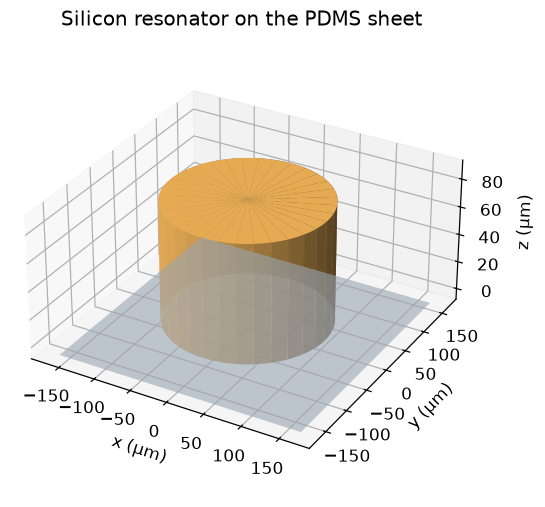

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.5), layout="constrained")
plot_freqs = np.linspace(.2*THz, 1*THz, 2000)
ax.plot(plot_freqs/THz, np.abs(pulse.spectrum(plot_freqs, normalize=True)), color="#a2448e")
ax.axvspan(.4, .8, color="#a2448e", alpha=.08, label="Monitor band")
ax.set(xlabel="Frequency (THz)", ylabel="Normalized source amplitude",
       title="Plane-wave pulse spectrum")
ax.legend()
plt.show()

unit_grid = absorber_grid(p, unit_steps_per_wavelength, periodic=True)
plot_setup(unit_grid, radius=radius, height=h, layer_bottom=-sheet_thickness,
           source_z=source_z, transmission_z=transmission_z,
           reflection_z=reflection_z,
           title="Periodic silicon resonator on PDMS: 40 cells per wavelength")
plt.show()
print(f"Unit-cell mesh: {unit_grid.shape}; {np.prod(unit_grid.shape):,} cells")

from _metasurface_utils import plot_disk_3d
plot_disk_3d(radius=radius, height=h, period=p, sheet_thickness=sheet_thickness)
plt.show()

## Running the unit-cell simulation

Run a vacuum reference with the same source, grid, and monitors, followed by the silicon/PDMS cell. This calibrates the incident pulse’s actual launched power. The backward monitor is behind the source; subtract its small reference field leakage before computing reflected power.

In [5]:
from dataclasses import replace


def reflected_monitor(actual, reference):
    return replace(actual, dft_fields={
        component: actual.dft_fields[component] - reference.dft_fields[component]
        for component in actual.dft_fields})


def power_spectra(actual, reference):
    incident = -reference["T"].flux
    assert np.min(incident) > 0
    reflection = reflected_monitor(actual["R"], reference["R"])
    R = reflection.flux / incident
    T = -actual["T"].flux / incident
    return R, T, 1 - R - T


release_device_memory()
unit_reference = run_case(absorber_simulation(device=False), "Vacuum unit-cell reference")
unit_actual = run_case(absorber_simulation(), "Periodic silicon / PDMS cell")
R, T, A = power_spectra(unit_actual, unit_reference)

Vacuum unit-cell reference: 37.6 s; 49,151 steps


Periodic silicon / PDMS cell: 54.4 s; 49,151 steps


## Result visualization: reflection, transmission, and absorption

Recreate the original R/T/A frequency plot, including its 0–1 power scale and 0.4–0.8 THz range. The source reports an absorption peak around 0.6 THz; the measured Beamz peak is printed below.

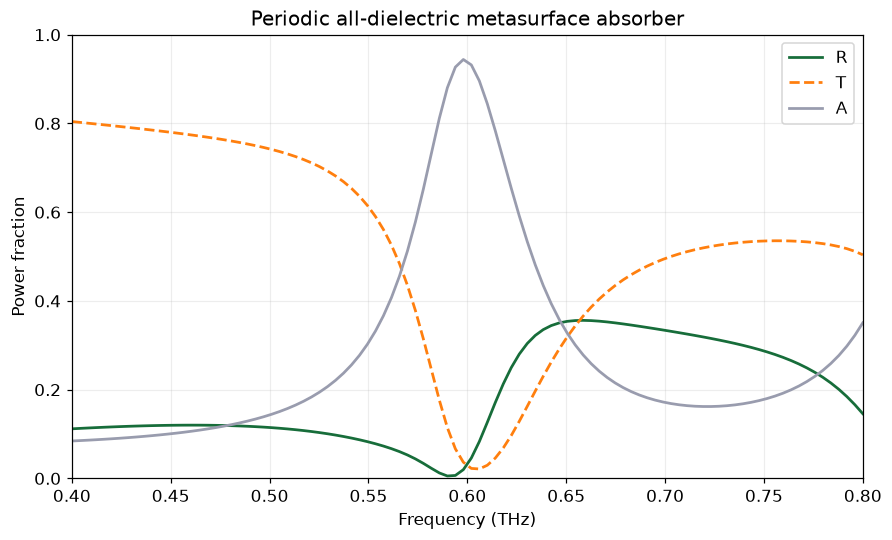

Peak absorption: 94.402% at 0.5980 THz


In [6]:
colors = {"R": "#176d3a", "T": "#ff7f0e", "A": "#999cae"}


def plot_rta(R, T, A, title):
    fig, ax = plt.subplots(figsize=(8, 4.8), layout="constrained")
    for name, values, style in [("R", R, "-"), ("T", T, "--"), ("A", A, "-")]:
        ax.plot(freqs/THz, values, color=colors[name], ls=style, label=name)
    ax.set(xlabel="Frequency (THz)", ylabel="Power fraction", xlim=(.4, .8),
           ylim=(0, 1), title=title)
    ax.legend()
    return fig, ax


plot_rta(R, T, A, "Periodic all-dielectric metasurface absorber")
plt.show()
peak_index = int(np.argmax(A))
print(f"Peak absorption: {A[peak_index]:.3%} at {freqs[peak_index]/THz:.4f} THz")

## Resonant field intensity

Plot |E|² on the x–z section at the original 0.6 THz design frequency. The map comes from the vector electric field DFT, including all three components.

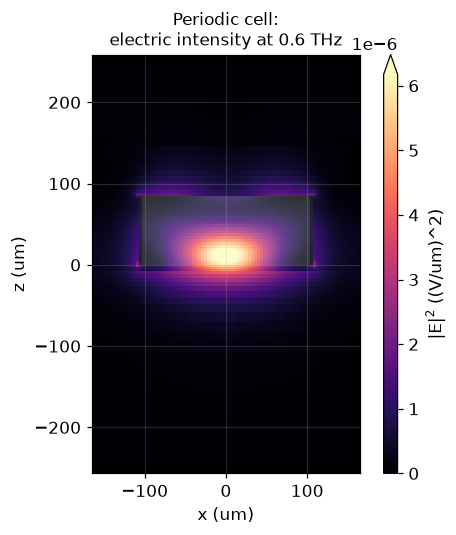

In [7]:
field_intensity(unit_actual, "resonance_xz", frequency=freq0,
                title="Periodic cell: electric intensity at 0.6 THz")
plt.show()

## Finite array of unit cells

Retain the source’s 15 × 15 array, centered here at the origin. The transverse buffer is half a wavelength on each side; a normally incident Gaussian beam has waist radius three wavelengths. CPML replaces lateral periodic boundaries. Source and flux apertures exclude transverse CPML, removing only weak beam tails.

The saved finite-array run uses a coarse 8-cell-per-wavelength silicon target rather than the source’s 30. Its field patterns and spectra are an illustrative finite-array comparison, not a mesh-converged reproduction. Set `finite_steps_per_wavelength = 30` above to request the original target, and inspect the printed cell budget before rerunning. Both targets retain the physical 8 µm sheet. The coarse uniform cells are thicker than the sheet; native subpixel averaging represents its material fractions, so sheet discretization is another source of error.

Finite array: 15 × 15 = 225 disks
Selected finite mesh: (314, 314, 58); 5,718,568 cells
Beamz uniform mesh at the source's 30-cell target: (1123, 1123, 206); 259,792,574 cells (before Yee/ADE/CPML buffers)


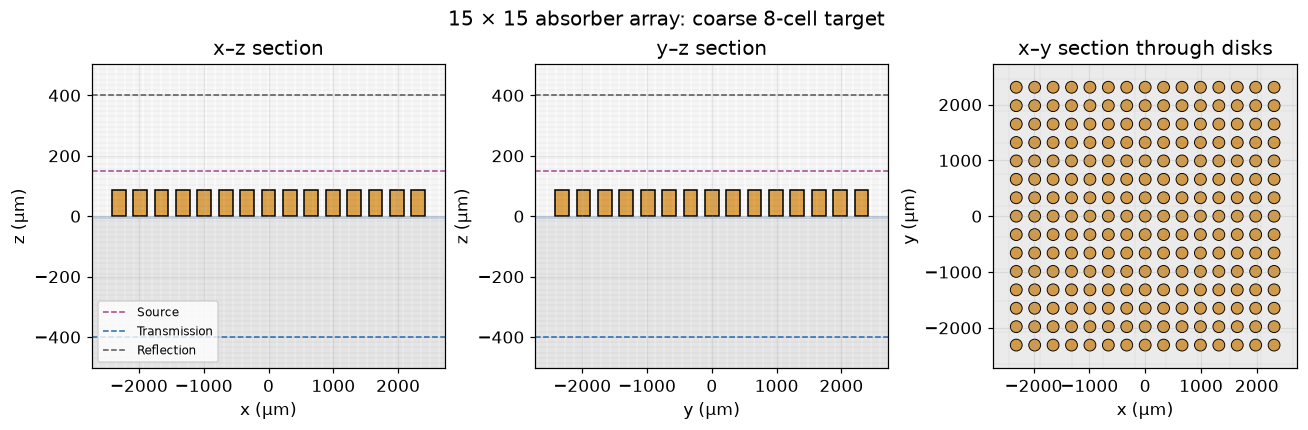

In [8]:
finite_width = finite_count*p + lambda0
finite_grid = absorber_grid(finite_width, finite_steps_per_wavelength, periodic=False, uniform=True)
reference_finite_grid = absorber_grid(finite_width, 30, periodic=False, uniform=True)
finite_centers = [(x, y) for x in p*(np.arange(finite_count)-(finite_count-1)/2)
                  for y in p*(np.arange(finite_count)-(finite_count-1)/2)]
print(f"Finite array: {finite_count} × {finite_count} = {len(finite_centers)} disks")
print(f"Selected finite mesh: {finite_grid.shape}; {np.prod(finite_grid.shape):,} cells")
print(f"Beamz uniform mesh at the source's 30-cell target: {reference_finite_grid.shape}; "
      f"{np.prod(reference_finite_grid.shape):,} cells (before Yee/ADE/CPML buffers)")
plot_setup(finite_grid, radius=radius, height=h, layer_bottom=-sheet_thickness,
           centers=finite_centers, source_z=source_z, transmission_z=transmission_z,
           reflection_z=reflection_z,
           title=f"15 × 15 absorber array: coarse {finite_steps_per_wavelength}-cell target")
plt.show()

### A periodic reference at the finite-array resolution

Repeat the periodic cell with the same uniform cell size and z extent as the selected finite-array mesh. The uniform domain extends by less than one cell to fit integer cell counts. Use this curve in the finite comparison so a resonance shift due to coarse discretization is visible.

In [9]:
release_device_memory()
coarse_reference = run_case(absorber_simulation(steps=finite_steps_per_wavelength, device=False, uniform=True),
                            "Coarse periodic vacuum reference")
coarse_actual = run_case(absorber_simulation(steps=finite_steps_per_wavelength, uniform=True),
                         "Coarse periodic absorber")
R_coarse, T_coarse, A_coarse = power_spectra(coarse_actual, coarse_reference)
del coarse_reference, coarse_actual

Coarse periodic vacuum reference: 5.3 s; 9,061 steps


Coarse periodic absorber: 2.8 s; 9,061 steps


### Run the Gaussian-beam finite array

Normalize against a vacuum Gaussian-beam run at the same mesh, beam waist, apertures, and acquisition duration. This measures total collected transmitted and reflected power, rather than only the zeroth diffraction order.

In [10]:
release_device_memory()
finite_reference = run_case(absorber_simulation(steps=finite_steps_per_wavelength,
                                              finite=True, device=False),
                            "Finite-aperture Gaussian vacuum reference")
release_device_memory()
finite_actual = run_case(absorber_simulation(steps=finite_steps_per_wavelength, finite=True),
                         "15 × 15 Gaussian-beam absorber")
R_finite, T_finite, A_finite = power_spectra(finite_actual, finite_reference)

Finite-aperture Gaussian vacuum reference: 70.4 s; 9,061 steps


15 × 15 Gaussian-beam absorber: 118.9 s; 9,061 steps


### Finite-array reflection, transmission, and absorption

Recreate the finite-array R/T/A plot, then compare absorption against both periodic meshes. Here 1 − R − T is **apparent absorptance**: unlike the periodic cell, finite arrays can scatter power laterally outside the two collection planes. A six-face power balance would be needed to isolate true material absorption.

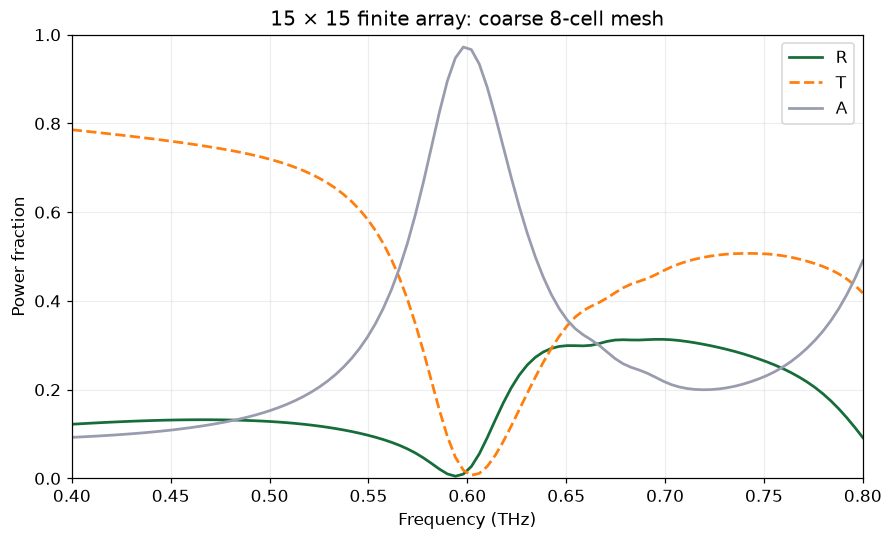

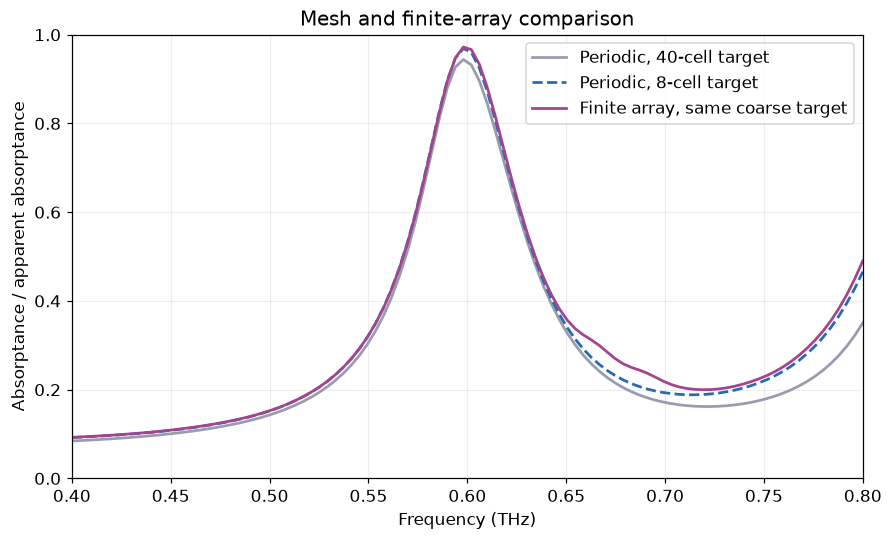

In [11]:
plot_rta(R_finite, T_finite, A_finite,
         f"15 × 15 finite array: coarse {finite_steps_per_wavelength}-cell mesh")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.8), layout="constrained")
ax.plot(freqs/THz, A, color="#999cae", label="Periodic, 40-cell target")
ax.plot(freqs/THz, A_coarse, color="#246bb2", ls="--",
        label=f"Periodic, {finite_steps_per_wavelength}-cell target")
ax.plot(freqs/THz, A_finite, color="#a2448e", label="Finite array, same coarse target")
ax.set(xlabel="Frequency (THz)", ylabel="Absorptance / apparent absorptance",
       xlim=(.4, .8), ylim=(0, 1), title="Mesh and finite-array comparison")
ax.legend()
plt.show()

### Finite-array field intensity

Match the original horizontal electric-intensity map at z = 0 and 0.6 THz. The Gaussian beam illuminates only part of the 15 × 15 array.

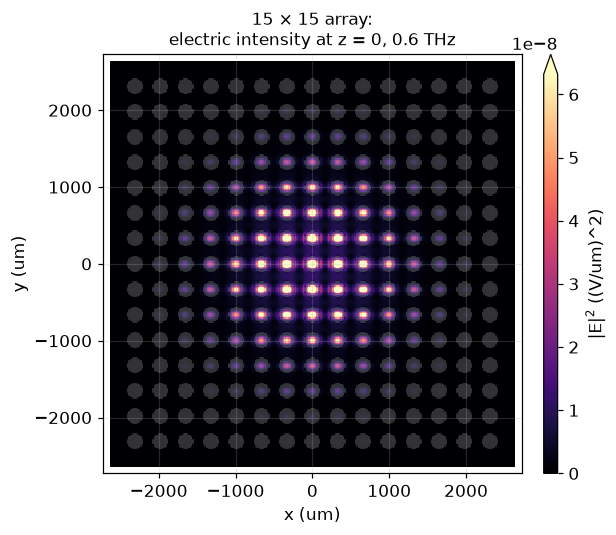

In [12]:
field_intensity(finite_actual, "array_xy", frequency=freq0,
                title="15 × 15 array: electric intensity at z = 0, 0.6 THz")
plt.show()

## Checks and reproducible results

Require finite, passive spectra within discretization tolerance and a resonance in the original THz band. Preserve the actual curves and mesh targets, rather than treating the source’s ~95% peak as a predetermined result.

In [13]:
for name, spectra in [("Periodic", (R, T, A)), ("Finite", (R_finite, T_finite, A_finite))]:
    values = np.asarray(spectra)
    assert np.isfinite(values).all(), name
    assert values.min() > -.06 and values.max() < 1.06, (name, values.min(), values.max())
assert .5 < freqs[peak_index]/THz < .7
print(f"Periodic peak: {A[peak_index]:.3%} at {freqs[peak_index]/THz:.4f} THz")
finite_peak = int(np.argmax(A_finite))
print(f"Finite apparent-absorption peak: {A_finite[finite_peak]:.3%} "
      f"at {freqs[finite_peak]/THz:.4f} THz")
print(f"Maximum periodic absorption change at coarse mesh: {np.max(abs(A-A_coarse)):.3f}")
output = REPO / "examples/results/dielectric_metasurface_absorber.npz"
output.parent.mkdir(exist_ok=True)
np.savez_compressed(output, frequency_hz=freqs,
                    unit_R=R, unit_T=T, unit_A=A,
                    coarse_R=R_coarse, coarse_T=T_coarse, coarse_A=A_coarse,
                    finite_R=R_finite, finite_T=T_finite, finite_A=A_finite,
                    unit_mesh_target=unit_steps_per_wavelength,
                    finite_mesh_target=finite_steps_per_wavelength,
                    finite_count=finite_count,
                    unit_shape=unit_grid.shape, finite_shape=finite_grid.shape)
print(f"Saved {output.relative_to(REPO)}")

Periodic peak: 94.402% at 0.5980 THz
Finite apparent-absorption peak: 97.204% at 0.5980 THz
Maximum periodic absorption change at coarse mesh: 0.115
Saved examples/results/dielectric_metasurface_absorber.npz


## Interpretation

The periodic cell tests the dispersive-material/ADE implementation and periodic plane-wave excitation together. The finite array tests Gaussian illumination, open lateral boundaries, and the effect of a finite collection aperture. Compare the saved peak and field patterns with the linked source notebook, allowing for mesh and subpixel differences. Quantitative agreement of the finite array requires refinement from the deliberately coarse default, and its apparent absorptance includes uncollected lateral scattering.

The saved run reaches **94.4% periodic absorption at 0.598 THz**, close to the source’s ~95% at 0.6 THz. The coarse periodic and finite-array peaks are 96.9% and 97.2%, respectively; the maximum absorption change between the coarse and fine periodic meshes is 0.115 across the band. The finite-array curve therefore demonstrates the workflow and field pattern; it does not establish a converged finite-array efficiency.